# Harris Hawks Optimization (HHO)

Ce notebook implémente l'algorithme d'optimisation **Harris Hawks Optimization (HHO)**.
L'algorithme est appliqué à un problème d'optimisation de conception de médicaments (Drug Design) utilisant des molécules sous forme de texte (SMILES), ainsi qu'à une fonction de test standard continue avec visualisation.

## Caractéristiques
- Typage statique (Type hints)
- Docstrings détaillés
- Visualisation de la convergence et de l'espace de recherche
- HHO continu (pour les fonctions mathématiques) et HHO discret (pour les séquences SMILES)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from typing import Callable, Tuple, List

def levy_flight(dim: int) -> np.ndarray:
    """
    Génère un pas de vol de Lévy.
    
    Args:
        dim (int): La dimension de l'espace de recherche.
        
    Returns:
        np.ndarray: Un vecteur numpy représentant le pas de Lévy.
    """
    beta = 1.5
    sigma = (math.gamma(1 + beta) * math.sin(math.pi * beta / 2) / 
             (math.gamma((1 + beta) / 2) * beta * 2**((beta - 1) / 2)))**(1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    step = u / np.abs(v)**(1 / beta)
    return step

[13:39:05] SMILES Parse Error: syntax error while parsing: )CC1=(C=CC=C1
[13:39:05] SMILES Parse Error: check for mistakes around position 1:
[13:39:05] )CC1=(C=CC=C1
[13:39:05] ^
[13:39:05] SMILES Parse Error: Failed parsing SMILES ')CC1=(C=CC=C1' for input: ')CC1=(C=CC=C1'
[13:39:05] SMILES Parse Error: syntax error while parsing: )C=CS(C=CCC=CS
[13:39:05] SMILES Parse Error: check for mistakes around position 1:
[13:39:05] )C=CS(C=CCC=CS
[13:39:05] ^
[13:39:05] SMILES Parse Error: Failed parsing SMILES ')C=CS(C=CCC=CS' for input: ')C=CS(C=CCC=CS'
[13:39:05] SMILES Parse Error: syntax error while parsing: CCC1=(C=CC=C1
[13:39:05] SMILES Parse Error: check for mistakes around position 6:
[13:39:05] CCC1=(C=CC=C1
[13:39:05] ~~~~~^
[13:39:05] SMILES Parse Error: Failed parsing SMILES 'CCC1=(C=CC=C1' for input: 'CCC1=(C=CC=C1'
[13:39:05] SMILES Parse Error: syntax error while parsing: C1=C==C1
[13:39:05] SMILES Parse Error: check for mistakes around position 6:
[13:39:05] C1=C==C1
[13:39

Meilleure molécule trouvée : CC1SCOS=CCOOCSN=COCC1
Poids Moléculaire : 299.44
Donneurs H : 1
Accepteurs H : 7
Score (à minimiser) : 8.56


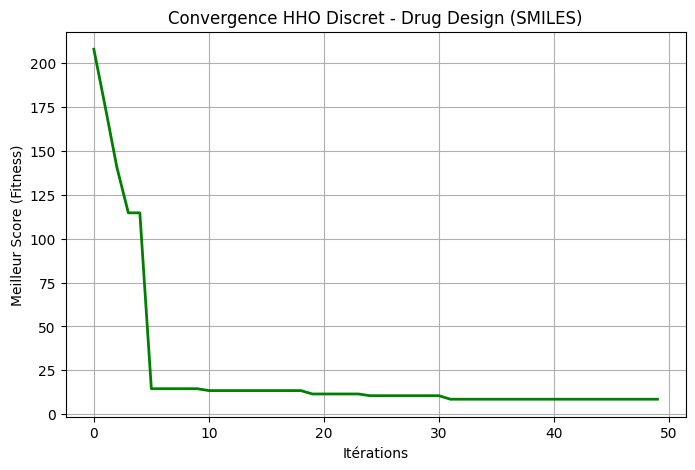

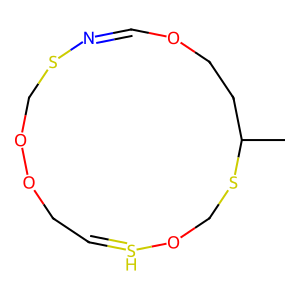

In [3]:
# --- Cas 1 : Optimisation de Conception de Médicaments avec molécules réelles (SMILES) ---
from rdkit import Chem
from rdkit.Chem import Descriptors
from IPython.display import display


# lazyPredict 
def smiles_fitness(smiles: str) -> float:
    """
    Évalue une molécule SMILES. 
    On veut minimiser la différence de poids moléculaire par rapport à 300,
    et minimiser le nombre de donneurs et d'accepteurs d'hydrogène.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return float('inf') # Pire score si la molécule est invalide
        
    mw = Descriptors.MolWt(mol)
    donors = Descriptors.NumHDonors(mol)
    acceptors = Descriptors.NumHAcceptors(mol)

    score = abs(mw - 300) + donors + acceptors
    return score

def mutate_smiles(smiles: str, intensity: float) -> str:
    """
    Mute une chaîne SMILES. L'intensité détermine le nombre de mutations.
    """
    chars = list(smiles)
    if len(chars) == 0: return "C"
    
    num_mutations = max(1, int(len(chars) * intensity))
    
    for _ in range(num_mutations):
        if len(chars) == 0: break
        i = random.randint(0, len(chars) - 1)
        action = random.choice(['sub', 'add', 'del'])
        
        if action == 'sub':
            chars[i] = random.choice(["C", "O", "N", "F", "S", "Cl", "(", ")", "=", "#"])
        elif action == 'add':
            chars.insert(i, random.choice(["C", "O", "N", "(", ")", "="]))
        elif action == 'del' and len(chars) > 1:
            chars.pop(i)
            
    return "".join(chars)

def crossover_smiles(smiles1: str, smiles2: str) -> str:
    """
    Croisement simple entre deux chaînes SMILES.
    """
    if len(smiles1) < 2 or len(smiles2) < 2: return smiles1
    cut1 = random.randint(1, len(smiles1)-1)
    cut2 = random.randint(1, len(smiles2)-1)
    return smiles1[:cut1] + smiles2[cut2:]

def hho_discrete(
    obj_func: Callable[[str], float],
    initial_population: List[str],
    max_iter: int = 50
) -> Tuple[str, float, List[float]]:
    """
    Version discrète de HHO adaptée aux chaînes de caractères (SMILES).
    """
    pop_size = len(initial_population)
    X = initial_population.copy()
    
    rabbit_location = ""
    rabbit_energy = float("inf")
    
    convergence_curve = []
    
    for t in range(max_iter):
        for i in range(pop_size):
            fitness = obj_func(X[i])
            if fitness < rabbit_energy:
                rabbit_energy = fitness
                rabbit_location = X[i]
                
        E1 = 2 * (1 - (t / max_iter))
        
        for i in range(pop_size):
            E0 = 2 * random.random() - 1
            E = E1 * E0
            
            if abs(E) >= 1:
                # Phase d'exploration
                q = random.random()
                rand_hawk_index = random.randint(0, pop_size - 1)
                X_rand = X[rand_hawk_index]
                
                if q >= 0.5:
                    X[i] = mutate_smiles(crossover_smiles(X[i], X_rand), intensity=0.3)
                else:
                    X[i] = mutate_smiles(X[i], intensity=0.8)
            else:
                # Phase d'exploitation
                r = random.random()
                
                if r >= 0.5 and abs(E) >= 0.5:
                    X[i] = mutate_smiles(crossover_smiles(X[i], rabbit_location), intensity=0.1)
                elif r >= 0.5 and abs(E) < 0.5:
                    X[i] = mutate_smiles(rabbit_location, intensity=0.1)
                elif r < 0.5 and abs(E) >= 0.5:
                    Y = crossover_smiles(X[i], rabbit_location)
                    if obj_func(Y) < obj_func(X[i]):
                        X[i] = Y
                    else:
                        Z = mutate_smiles(Y, intensity=0.3)
                        if obj_func(Z) < obj_func(X[i]):
                            X[i] = Z
                elif r < 0.5 and abs(E) < 0.5:
                    Y = mutate_smiles(rabbit_location, intensity=0.2)
                    if obj_func(Y) < obj_func(X[i]):
                        X[i] = Y
                    else:
                        Z = mutate_smiles(Y, intensity=0.4)
                        if obj_func(Z) < obj_func(X[i]):
                            X[i] = Z

        convergence_curve.append(rabbit_energy)
        
    return rabbit_location, rabbit_energy, convergence_curve

# --- Exécution du HHO Discret ---
initial_smiles_pop = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",
    "C1=CC=CC=C1", "CC(C)C", "C=C", "CC#N", "C1CCCCC1",
    "C(C(=O)O)N", "c1cc(O)ccc1", "C1=CN=CN1", "C1=CC=NC=C1", "C1COCCO1",
    "CC1=CC=CC=C1", "CC(=O)C", "CC(O)C", "C1=CC=C(C=C1)O", "C1=CC=C(C=C1)N"
]

best_smiles, best_score, conv_curve_smiles = hho_discrete(
    obj_func=smiles_fitness, 
    initial_population=initial_smiles_pop, 
    max_iter=50
)

print("Meilleure molécule trouvée :", best_smiles)
mol = Chem.MolFromSmiles(best_smiles)
if mol:
    print(f"Poids Moléculaire : {Descriptors.MolWt(mol):.2f}")
    print(f"Donneurs H : {Descriptors.NumHDonors(mol)}")
    print(f"Accepteurs H : {Descriptors.NumHAcceptors(mol)}")
print(f"Score (à minimiser) : {best_score:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(conv_curve_smiles, linewidth=2, color='g')
plt.title('Convergence HHO Discret - Drug Design (SMILES)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur Score (Fitness)')
plt.grid(True)
plt.show()

if mol:
    from rdkit.Chem import Draw
    img = Draw.MolToImage(mol)
    display(img)

# --- Cas 3 : Utilisation du modèle RandomForest comme fonction objective ---

Le bloc ci-dessous utilise le modèle pré-entraîné de machine learning (`pIC50_prediction_pipeline.pkl`) pour guider l'optimisation.

**Architecture du modèle :**
1. `VarianceThreshold` filtre les 895 features en 155 features pertinentes.
2. Le `RandomForestRegressor` (extrait du `LazyRegressor`) prédit le `pIC50`.

**Améliorations apportées :**
- Validation SMILES après chaque mutation/crossover pour éviter les molécules invalides.
- Cache des résultats pour accélérer l'évaluation.
- Extraction directe du RandomForest depuis le LazyRegressor.

In [5]:
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display

print('Imports OK')

Imports OK


In [6]:
# --- Chargement du modèle ---
print("Chargement du modèle...")
full_pipeline = joblib.load('RandomForestRegressor_model/pIC50_prediction_pipeline.pkl')

# Extraire le VarianceThreshold et le RandomForestRegressor
variance_filter = full_pipeline.named_steps['filter']
lazy_regressor = full_pipeline.named_steps['brain']
rf_model = lazy_regressor.models['RandomForestRegressor']

# Noms des features attendues par le VarianceThreshold (895 features)
input_feature_names = list(variance_filter.feature_names_in_)
# Noms des features sélectionnées après filtrage (155 features)
selected_feature_names = list(variance_filter.get_feature_names_out())

print(f"Features en entrée : {len(input_feature_names)}")
print(f"Features sélectionnées : {len(selected_feature_names)}")
print("Modèle chargé avec succès !")

Chargement du modèle...
Features en entrée : 895
Features sélectionnées : 155
Modèle chargé avec succès !


In [7]:
# --- Cache et fonction objectif ML ---
fitness_cache = {}

def compute_lipinski_features(mol):
    """Calcule les 14 descripteurs moléculaires de type Lipinski."""
    desc_MolWt = Descriptors.MolWt(mol)
    desc_MolLogP = Descriptors.MolLogP(mol)
    desc_NumHDonors = Lipinski.NumHDonors(mol)
    desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
    SaScore = calculateScore(mol)
    qed_val = QED.qed(mol)
    RB = Descriptors.NumRotatableBonds(mol)
    AP = Descriptors.FractionCSP3(mol)
    logS = 0.16 - 0.63*desc_MolLogP - 0.0062*desc_MolWt + 0.066*RB - 0.74*AP
    tpsa = Descriptors.TPSA(mol)
    mol_volume = rdMolDescriptors.CalcExactMolWt(mol)
    n_atoms = mol.GetNumAtoms()
    n_bonds = mol.GetNumBonds()
    n_total = mol.GetNumAtoms()
    aromatic_proportion = rdMolDescriptors.CalcNumAromaticRings(mol) / n_total if n_total > 0 else 0
    return [
        desc_MolWt, desc_MolLogP, desc_NumHDonors, desc_NumHAcceptors,
        SaScore, qed_val, RB, AP, logS, tpsa, mol_volume,
        n_atoms, n_bonds, aromatic_proportion
    ]

def ml_smiles_fitness(smiles: str) -> float:
    """
    Évalue une molécule SMILES en utilisant le modèle RandomForest.
    Retourne -pIC50 (HHO minimise, on veut maximiser pIC50).
    """
    if smiles in fitness_cache:
        return fitness_cache[smiles]

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 100.0  # Pénalité pour molécule invalide

    try:
        # 1. Descripteurs Lipinski (14 features)
        lipinski_values = compute_lipinski_features(mol)

        # 2. Empreintes PubChem via PaDEL
        fps = from_smiles(smiles, fingerprints=True)
        pubchem_values = [float(fps.get(fname, 0.0)) for fname in input_feature_names[14:]]

        # 3. Construire le DataFrame avec les 895 features
        total_values = lipinski_values + pubchem_values
        X_full = pd.DataFrame([total_values], columns=input_feature_names)

        # 4. Appliquer le VarianceThreshold
        X_filtered = pd.DataFrame(
            variance_filter.transform(X_full),
            columns=selected_feature_names
        )

        # 5. Prédire avec le RandomForest extrait
        pIC50 = rf_model.predict(X_filtered)[0]

        fitness_score = -pIC50  # Minimiser => maximiser pIC50
        fitness_cache[smiles] = fitness_score
        return fitness_score

    except Exception as e:
        print(f"  [Erreur] {smiles}: {e}")
        return 100.0

# --- Test rapide ---
test_smiles = 'c1ccccc1'
score = ml_smiles_fitness(test_smiles)
print(f"Test: {test_smiles} => pIC50 prédit = {-score:.4f}")

Test: c1ccccc1 => pIC50 prédit = 4.6377


In [8]:
# --- Opérateurs de mutation/crossover avec validation SMILES ---

def is_valid_smiles(smiles: str) -> bool:
    """Vérifie si un SMILES est chimiquement valide."""
    if not smiles:
        return False
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

def safe_mutate_smiles(smiles: str, intensity: float, max_attempts: int = 10) -> str:
    """
    Mute une chaîne SMILES avec validation.
    Réessaie jusqu'à max_attempts fois pour obtenir une molécule valide.
    Si aucune mutation valide n'est trouvée, retourne le SMILES original.
    """
    for _ in range(max_attempts):
        candidate = mutate_smiles(smiles, intensity)
        if is_valid_smiles(candidate):
            return candidate
    return smiles  # Retourner l'original si aucune mutation valide

def safe_crossover_smiles(smiles1: str, smiles2: str, max_attempts: int = 10) -> str:
    """
    Croisement entre deux SMILES avec validation.
    Réessaie jusqu'à max_attempts fois pour obtenir une molécule valide.
    Si aucun croisement valide n'est trouvé, retourne smiles1.
    """
    for _ in range(max_attempts):
        candidate = crossover_smiles(smiles1, smiles2)
        if is_valid_smiles(candidate):
            return candidate
    return smiles1

print('Opérateurs safe définis.')

Opérateurs safe définis.


In [9]:
def hho_discrete_ml(
    obj_func,
    initial_population,
    max_iter: int = 50
):
    """
    Version discrète de HHO avec mutations/crossovers sécurisés.
    Utilise safe_mutate_smiles et safe_crossover_smiles pour
    garantir que seules des molécules valides sont générées.
    """
    pop_size = len(initial_population)
    X = initial_population.copy()

    rabbit_location = ""
    rabbit_energy = float("inf")
    convergence_curve = []

    for t in range(max_iter):
        # Évaluation de la population
        for i in range(pop_size):
            fitness = obj_func(X[i])
            if fitness < rabbit_energy:
                rabbit_energy = fitness
                rabbit_location = X[i]

        E1 = 2 * (1 - (t / max_iter))

        for i in range(pop_size):
            E0 = 2 * random.random() - 1
            E = E1 * E0

            if abs(E) >= 1:
                # Phase d'exploration
                q = random.random()
                rand_hawk_index = random.randint(0, pop_size - 1)
                X_rand = X[rand_hawk_index]

                if q >= 0.5:
                    X[i] = safe_mutate_smiles(safe_crossover_smiles(X[i], X_rand), intensity=0.3)
                else:
                    X[i] = safe_mutate_smiles(X[i], intensity=0.8)
            else:
                # Phase d'exploitation
                r = random.random()

                if r >= 0.5 and abs(E) >= 0.5:
                    X[i] = safe_mutate_smiles(safe_crossover_smiles(X[i], rabbit_location), intensity=0.1)
                elif r >= 0.5 and abs(E) < 0.5:
                    X[i] = safe_mutate_smiles(rabbit_location, intensity=0.1)
                elif r < 0.5 and abs(E) >= 0.5:
                    Y = safe_crossover_smiles(X[i], rabbit_location)
                    if obj_func(Y) < obj_func(X[i]):
                        X[i] = Y
                    else:
                        Z = safe_mutate_smiles(Y, intensity=0.3)
                        if obj_func(Z) < obj_func(X[i]):
                            X[i] = Z
                elif r < 0.5 and abs(E) < 0.5:
                    Y = safe_mutate_smiles(rabbit_location, intensity=0.2)
                    if obj_func(Y) < obj_func(X[i]):
                        X[i] = Y
                    else:
                        Z = safe_mutate_smiles(Y, intensity=0.4)
                        if obj_func(Z) < obj_func(X[i]):
                            X[i] = Z

        convergence_curve.append(rabbit_energy)
        print(f"  Itération {t+1}/{max_iter} | Meilleur pIC50 = {-rabbit_energy:.4f} | Molécule = {rabbit_location}")

    return rabbit_location, rabbit_energy, convergence_curve

print('HHO discret ML défini.')

HHO discret ML défini.


In [ ]:
print("=" * 60)
print("Démarrage de l'optimisation HHO avec le modèle ML")
print("=" * 60)
print("Note : Le calcul PaDEL est lent (~2s par molécule).")
print("Population réduite pour la démonstration.\n")

initial_smiles_pop_ml = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN"
]

best_smiles_ml, best_score_ml, conv_curve_ml = hho_discrete_ml(
    obj_func=ml_smiles_fitness,
    initial_population=initial_smiles_pop_ml,
    max_iter=5
)

print(f"\n{'=' * 60}")
print(f"Meilleure molécule trouvée : {best_smiles_ml}")
print(f"Meilleur pIC50 prédit     : {-best_score_ml:.4f}")
print(f"{'=' * 60}")

# Convergence
plt.figure(figsize=(8, 5))
plt.plot([-s for s in conv_curve_ml], linewidth=2, color='b', marker='o')
plt.title('Convergence HHO Discret - Modèle RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True)
plt.show()

# Affichage de la molécule
mol_ml = Chem.MolFromSmiles(best_smiles_ml)
if mol_ml:
    img = Draw.MolToImage(mol_ml, size=(300, 300))
    display(img)

Démarrage de l'optimisation HHO avec le modèle ML
Note : Le calcul PaDEL est lent (~2s par molécule).
Population réduite pour la démonstration.



[13:40:18] SMILES Parse Error: extra open parentheses while parsing: CC(=N
[13:40:18] SMILES Parse Error: check for mistakes around position 3:
[13:40:18] CC(=N
[13:40:18] ~~^
[13:40:18] SMILES Parse Error: Failed parsing SMILES 'CC(=N' for input: 'CC(=N'
[13:40:18] SMILES Parse Error: extra open parentheses while parsing: CC(=OCN
[13:40:18] SMILES Parse Error: check for mistakes around position 3:
[13:40:18] CC(=OCN
[13:40:18] ~~^
[13:40:18] SMILES Parse Error: Failed parsing SMILES 'CC(=OCN' for input: 'CC(=OCN'
[13:40:18] SMILES Parse Error: extra open parentheses while parsing: CC(=OCN
[13:40:18] SMILES Parse Error: check for mistakes around position 3:
[13:40:18] CC(=OCN
[13:40:18] ~~^
[13:40:18] SMILES Parse Error: Failed parsing SMILES 'CC(=OCN' for input: 'CC(=OCN'
[13:40:18] SMILES Parse Error: syntax error while parsing: =CC(C
[13:40:18] SMILES Parse Error: check for mistakes around position 1:
[13:40:18] =CC(C
[13:40:18] ^
[13:40:18] SMILES Parse Error: Failed parsing SMILES

  Itération 1/5 | Meilleur pIC50 = 5.7638 | Molécule = CCN
  [Erreur] C: [WinError 32] Le processus ne peut pas accéder au fichier car ce fichier est utilisé par un autre processus: '20260425134026513153.csv'
  [Erreur] C=C: [WinError 32] Le processus ne peut pas accéder au fichier car ce fichier est utilisé par un autre processus: '20260425134331562841.csv'


[13:44:10] SMILES Parse Error: syntax error while parsing: (CCN
[13:44:10] SMILES Parse Error: check for mistakes around position 1:
[13:44:10] (CCN
[13:44:10] ^
[13:44:10] SMILES Parse Error: Failed parsing SMILES '(CCN' for input: '(CCN'
